# Cleaning BRFSS 2015 for Diabetes-Risk Modelling

The raw file `2015.csv` is the CDC **Behavioral Risk Factor Surveillance System
(BRFSS) 2015** survey: **441,456 respondents × 330 columns** of survey codes.

**Goal of this notebook** — turn that raw survey into a small, tidy, analysis-ready
table for predicting diabetes risk:

1. **Target** — recode `DIABETE3` into three *stages*:
   `0 = no diabetes`, `1 = pre-diabetes / borderline`, `2 = diabetes`.
2. **Cofactors** — keep only the risk factors known to matter for diabetes /
   chronic disease (blood pressure, cholesterol, smoking, obesity/BMI, age, sex,
   race, diet, exercise, alcohol, income, marital status, checkup recency,
   education, healthcare coverage, mental health, …) and **drop the other ~300
   columns**.
3. **Recode** every kept column from its BRFSS numeric code into a clean,
   human-meaningful value, dropping *Don't know / Refused / Missing* responses.
4. **Save** the result to `diabetes_2015_clean.csv`.

> Every recode below follows the official *BRFSS 2015 Codebook*. Calculated
> variables (the `_`-prefixed ones such as `_RFHYPE5`, `_BMI5`, `_AGEG5YR`) are
> CDC's own cleaned/derived fields, so we prefer them over the raw questions
> where one exists.

## 1. Setup & load only the columns we need

The raw CSV is ~540 MB. Loading all 330 columns wastes memory, so we read only
the ~26 source columns this cleaning touches via `usecols`.

In [1]:
import numpy as np
import pandas as pd

RAW_PATH   = '../data/raw/2015.csv'
CLEAN_PATH = '../data/processed/diabetes_2015_clean.csv'

# Raw BRFSS columns we will use as SOURCES for the clean features
SRC_COLS = [
    'DIABETE3',                                   # target
    '_RFHYPE5', 'TOLDHI2', '_CHOLCHK',            # BP / cholesterol
    '_BMI5', '_BMI5CAT',                          # obesity / BMI
    'SMOKE100', '_SMOKER3',                       # smoking
    'CVDSTRK3', '_MICHD',                         # comorbid cardiovascular
    'CHCKIDNY', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2',# other chronic comorbidities
    '_TOTINDA', '_PACAT1', '_FRTLT1', '_VEGLT1',  # exercise / diet
    '_RFDRHV5',                                   # heavy alcohol
    'HLTHPLN1', 'MEDCOST',                        # healthcare access
    'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'DIFFWALK',# general / mental / physical health
    'SEX', '_AGEG5YR', '_AGE80', '_RACE', 'MARITAL',# demographics
    'EDUCA', 'INCOME2', 'EMPLOY1', 'CHECKUP1',    # SES / checkup recency
]

raw = pd.read_csv(RAW_PATH, usecols=SRC_COLS)
print(f'Raw subset loaded: {raw.shape[0]:,} rows × {raw.shape[1]} source columns')
raw.head()

Raw subset loaded: 441,456 rows × 34 source columns


,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,MEDCOST,CHECKUP1,TOLDHI2,CVDSTRK3,CHCCOPD1,HAVARTH3,...,_AGEG5YR,_AGE80,_BMI5,_BMI5CAT,_SMOKER3,_RFDRHV5,_FRTLT1,_VEGLT1,_TOTINDA,_PACAT1
0,5.0,15.0,18.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,...,9.0,63.0,4018.0,4.0,3.0,1.0,2.0,1.0,2.0,4.0
1,3.0,88.0,88.0,2.0,1.0,4.0,2.0,2.0,2.0,2.0,...,7.0,52.0,2509.0,3.0,1.0,1.0,2.0,2.0,1.0,2.0
2,4.0,15.0,88.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,...,11.0,71.0,2204.0,2.0,9.0,9.0,9.0,9.0,9.0,9.0
3,5.0,30.0,30.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,...,9.0,63.0,2819.0,3.0,4.0,1.0,1.0,2.0,2.0,4.0
4,5.0,20.0,88.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,...,9.0,61.0,2437.0,2.0,4.0,1.0,9.0,1.0,2.0,4.0


## 2. The target — diabetes *stage* from `DIABETE3`

`DIABETE3` asks *"(Ever told) you have diabetes?"*. Its codes:

| code | meaning | Diabetes stage |
|------|---------|-------------|
| 1 | Yes | **2 — Diabetes** |
| 2 | Yes, but only during pregnancy | 0 — No diabetes* |
| 3 | No | **0 — No diabetes** |
| 4 | No, pre-diabetes or borderline | **1 — Pre-diabetes** |
| 7 / 9 | Don't know / Refused | drop |

\*Gestational-only diabetes is treated as "no diabetes" for chronic-risk purposes,
which is the standard convention for this dataset.

In [2]:
stage_map = {1: 2, 2: 0, 3: 0, 4: 1}          # 7, 9, NaN -> dropped below
df = raw.copy()
df['DiabetesStage'] = df['DIABETE3'].map(stage_map)

before = len(df)
df = df.dropna(subset=['DiabetesStage'])
df['DiabetesStage'] = df['DiabetesStage'].astype(int)
print(f'Dropped {before - len(df):,} rows with unusable diabetes status '
      f'(Don\'t know / Refused / Missing)')

labels = {0: 'No diabetes', 1: 'Pre-diabetes', 2: 'Diabetes'}
dist = df['DiabetesStage'].value_counts().sort_index()
for k, n in dist.items():
    print(f'  {k} {labels[k]:<13}: {n:>7,}  ({n/len(df):5.1%})')

Dropped 798 rows with unusable diabetes status (Don't know / Refused / Missing)
  0 No diabetes  : 375,712  (85.3%)
  1 Pre-diabetes :   7,690  ( 1.7%)
  2 Diabetes     :  57,256  (13.0%)


## 3. Risk-factor's BRFSS variable map

Every requested risk factor is matched to the best available BRFSS 2015 column.
Binary flags are coded **1 = yes / has-risk, 0 = no** unless noted.

| Risk factor | Clean column | Source | Encoding |
|---|---|---|---|
| High blood pressure | `HighBP` | `_RFHYPE5` | 1=yes,0=no |
| High cholesterol | `HighChol` | `TOLDHI2` | 1=yes,0=no |
| Cholesterol checked (â‰¤5y) | `CholCheck` | `_CHOLCHK` | 1=yes,0=no |
| BMI | `BMI` | `_BMI5` | continuous |
| Obesity band | `BMICategory` | `_BMI5CAT` | 1=under,2=normal,3=over,4=obese |
| Smoking (â‰¥100 cigs) | `Smoker` | `SMOKE100` | 1=yes,0=no |
| Smoking status | `SmokerStatus` | `_SMOKER3` | 0=never,1=former,2=some days,3=daily |
| Stroke history | `Stroke` | `CVDSTRK3` | 1=yes,0=no |
| Heart disease / MI | `HeartDiseaseorAttack` | `_MICHD` | 1=yes,0=no |
| Kidney disease | `KidneyDisease` | `CHCKIDNY` | 1=yes,0=no |
| COPD | `COPD` | `CHCCOPD1` | 1=yes,0=no |
| Arthritis | `Arthritis` | `HAVARTH3` | 1=yes,0=no |
| Depression (ever told) | `Depression` | `ADDEPEV2` | 1=yes,0=no |
| Exercise (any, 30d) | `PhysActivity` | `_TOTINDA` | 1=yes,0=no |
| Physical-activity level | `PhysActivityLevel` | `_PACAT1` | 1=highly active…4=inactive |
| Diet – fruit ≥1/day | `Fruits` | `_FRTLT1` | 1=yes,0=no |
| Diet – veg ≥1/day | `Veggies` | `_VEGLT1` | 1=yes,0=no |
| Heavy alcohol use | `HvyAlcoholConsump` | `_RFDRHV5` | 1=yes,0=no |
| Healthcare coverage | `AnyHealthcare` | `HLTHPLN1` | 1=yes,0=no |
| Skipped doctor (cost) | `NoDocbcCost` | `MEDCOST` | 1=yes,0=no |
| General health | `GenHlth` | `GENHLTH` | 1=excellent…5=poor |
| Mental health (bad days/30) | `MentHlth` | `MENTHLTH` | 0–30 |
| Physical health (bad days/30) | `PhysHlth` | `PHYSHLTH` | 0–30 |
| Difficulty walking | `DiffWalk` | `DIFFWALK` | 1=yes,0=no |
| Sex | `Sex` | `SEX` | 1=male,0=female |
| Age band | `Age` | `_AGEG5YR` | 1–13 (5-yr bands) |
| Age in years | `AgeYears` | `_AGE80` | 18–80 continuous |
| Race / ethnicity | `Race` | `_RACE` | 1–8 category |
| Marital status | `MaritalStatus` | `MARITAL` | 1–6 category |
| Education | `Education` | `EDUCA` | 1–6 ordinal |
| Household income | `Income` | `INCOME2` | 1–8 ordinal |
| Employment status | `Employment` | `EMPLOY1` | 1–8 category |
| Time since last checkup | `CheckupTime` | `CHECKUP1` | 1=≤1y…4=5y+, 5=never |

**Not available in BRFSS 2015 core:** *Sleep* — there is no general sleep-duration
question in the 2015 file (the only sleep fields belong to optional asthma /
depression modules asked of small sub-samples), so sleep is **excluded** rather
than filled with mostly-missing data.

## 4. Recode every cofactor

We build the clean columns from the raw codes. `pd.Series.map` leaves any value
not in the mapping as `NaN`, which conveniently turns every *Don't know / Refused*
code into a missing value that we drop in the next step.

In [3]:
yes1_no2 = {1: 1, 2: 0}      # BRFSS 'Yes=1 / No=2' questions -> 1/0
rf_no1_yes2 = {1: 0, 2: 1}   # BRFSS calculated risk flags 'No=1 / Yes=2' -> 0/1

clean = pd.DataFrame({'DiabetesStage': df['DiabetesStage']})

# --- Blood pressure & cholesterol ------------------------------------------
clean['HighBP']    = df['_RFHYPE5'].map(rf_no1_yes2)
clean['HighChol']  = df['TOLDHI2'].map(yes1_no2)
clean['CholCheck'] = df['_CHOLCHK'].map({1: 1, 2: 0, 3: 0})   # 3 = never checked

# --- Obesity / BMI ----------------------------------------------------------
clean['BMI']         = df['_BMI5'] / 100.0                     # _BMI5 is BMI × 100
clean['BMICategory'] = df['_BMI5CAT']                          # 1..4, NaN dropped later

# --- Smoking & cardiovascular comorbidities --------------------------------
clean['Smoker']               = df['SMOKE100'].map(yes1_no2)
clean['SmokerStatus']         = df['_SMOKER3'].map({4: 0, 3: 1, 2: 2, 1: 3})  # never->daily; 9 drop
clean['Stroke']               = df['CVDSTRK3'].map(yes1_no2)
clean['HeartDiseaseorAttack'] = df['_MICHD'].map(yes1_no2)

# --- Other chronic comorbidities that co-occur with diabetes ---------------
clean['KidneyDisease'] = df['CHCKIDNY'].map(yes1_no2)
clean['COPD']          = df['CHCCOPD1'].map(yes1_no2)
clean['Arthritis']     = df['HAVARTH3'].map(yes1_no2)
clean['Depression']    = df['ADDEPEV2'].map(yes1_no2)

# --- Exercise & diet --------------------------------------------------------
clean['PhysActivity']      = df['_TOTINDA'].map(yes1_no2)
clean['PhysActivityLevel'] = df['_PACAT1'].where(df['_PACAT1'].between(1, 4))  # 9 = missing
clean['Fruits']            = df['_FRTLT1'].map(yes1_no2)
clean['Veggies']           = df['_VEGLT1'].map(yes1_no2)

# --- Alcohol & healthcare access -------------------------------------------
clean['HvyAlcoholConsump'] = df['_RFDRHV5'].map(rf_no1_yes2)
clean['AnyHealthcare']     = df['HLTHPLN1'].map(yes1_no2)
clean['NoDocbcCost']       = df['MEDCOST'].map(yes1_no2)

# --- General / mental / physical health ------------------------------------
clean['GenHlth']  = df['GENHLTH'].where(df['GENHLTH'].between(1, 5))
clean['MentHlth'] = df['MENTHLTH'].replace(88, 0).where(df['MENTHLTH'].isin(list(range(1, 31)) + [88]))
clean['PhysHlth'] = df['PHYSHLTH'].replace(88, 0).where(df['PHYSHLTH'].isin(list(range(1, 31)) + [88]))
clean['DiffWalk'] = df['DIFFWALK'].map(yes1_no2)

# --- Demographics -----------------------------------------------------------
clean['Sex']           = df['SEX'].map({1: 1, 2: 0})           # 1 male / 0 female
clean['Age']           = df['_AGEG5YR'].where(df['_AGEG5YR'].between(1, 13))  # 14 = missing
clean['AgeYears']      = df['_AGE80']                          # imputed age 18-80, no missing
clean['Race']          = df['_RACE'].where(df['_RACE'].between(1, 8))         # 9  = missing
clean['MaritalStatus'] = df['MARITAL'].where(df['MARITAL'].between(1, 6))     # 9  = refused

# --- SES & checkup recency --------------------------------------------------
clean['Education']   = df['EDUCA'].where(df['EDUCA'].between(1, 6))           # 9  = refused
clean['Income']      = df['INCOME2'].where(df['INCOME2'].between(1, 8))       # 77,99 dropped
clean['Employment']  = df['EMPLOY1'].where(df['EMPLOY1'].between(1, 8))       # 9  = refused
clean['CheckupTime'] = df['CHECKUP1'].map({1: 1, 2: 2, 3: 3, 4: 4, 8: 5})    # 8 never->5; 7,9 drop

print(f'Built {clean.shape[1]-1} clean cofactors + target')
clean.head()

Built 33 clean cofactors + target


,DiabetesStage,HighBP,HighChol,CholCheck,BMI,BMICategory,Smoker,SmokerStatus,Stroke,HeartDiseaseorAttack,...,DiffWalk,Sex,Age,AgeYears,Race,MaritalStatus,Education,Income,Employment,CheckupTime
0,0,1.0,1.0,1.0,40.18,4.0,1.0,1.0,0.0,0.0,...,1.0,0,9.0,63.0,1.0,1.0,4.0,3.0,8.0,1.0
1,0,0.0,0.0,0.0,25.09,3.0,1.0,3.0,0.0,0.0,...,0.0,0,7.0,52.0,1.0,2.0,6.0,1.0,3.0,4.0
2,0,0.0,1.0,1.0,22.04,2.0,NaN,NaN,1.0,NaN,...,NaN,0,11.0,71.0,1.0,2.0,4.0,NaN,7.0,1.0
3,0,1.0,1.0,1.0,28.19,3.0,0.0,0.0,0.0,0.0,...,1.0,0,9.0,63.0,1.0,1.0,4.0,8.0,8.0,1.0
4,0,0.0,0.0,1.0,24.37,2.0,0.0,0.0,0.0,0.0,...,0.0,0,9.0,61.0,1.0,1.0,5.0,NaN,8.0,1.0


## 5. Missingness audit — what would a complete-case filter cost us?

Before dropping incomplete rows we quantify *where* the missingness lives, so the
large row loss is an informed decision rather than a silent one. This shows which
survey questions (typically `Income`, `Employment`, `PhysActivityLevel`) drive most
of the drop, and lets a future modeller decide which columns are worth imputing
instead of dropping.

In [4]:
# Missingness per clean column. Every Don't-know / Refused / Missing code became a
# NaN during recoding, so this is exactly the set of rows the next step will drop.
row_has_na = clean.isna().any(axis=1)
print(f'{row_has_na.sum():,} of {len(clean):,} rows ({row_has_na.mean():.1%}) '
      f'have >=1 missing value and would be dropped by a complete-case filter.\n')

miss   = clean.isna().sum()
miss   = miss[miss > 0].sort_values(ascending=False)
report = pd.concat([miss.rename('n_missing'),
                    (miss / len(clean) * 100).round(2).rename('pct_of_rows')], axis=1)
print('Columns driving the missingness (worst first):')
print(report.to_string())

199,927 of 440,658 rows (45.4%) have >=1 missing value and would be dropped by a complete-case filter.

Columns driving the missingness (worst first):
                      n_missing  pct_of_rows
Income                    79169        17.97
HighChol                  62422        14.17
PhysActivityLevel         55662        12.63
Veggies                   50921        11.56
Fruits                    43530         9.88
PhysActivity              37850         8.59
BMI                       36191         8.21
BMICategory               36191         8.21
HvyAlcoholConsump         25595         5.81
SmokerStatus              17888         4.06
Smoker                    17451         3.96
CholCheck                 15230         3.46
DiffWalk                  14503         3.29
PhysHlth                   9679         2.20
MentHlth                   7344         1.67
Race                       7341         1.67
CheckupTime                6065         1.38
Age                        5234        

## 6. Drop rows with any missing / refused value

Because every unusable code became `NaN` above, a single `dropna` removes all the
*Don't know / Refused / Missing* responses at once. (For a modelling notebook you
might instead impute these — see the audit in §5 — but the brief here is a **clean**
testing dataset, so we keep only complete cases.)

In [5]:
before = len(clean)
clean = clean.dropna().reset_index(drop=True)

# Everything except continuous BMI is integer-valued -> tidy up the dtypes
int_cols = [c for c in clean.columns if c != 'BMI']
clean[int_cols] = clean[int_cols].astype(int)

print(f'Complete-case rows kept: {len(clean):,}  (dropped {before - len(clean):,}, '
      f'{(before-len(clean))/before:.1%} of the diabetes-labelled sample)')
print(f'Final shape: {clean.shape[0]:,} rows × {clean.shape[1]} columns')

Complete-case rows kept: 240,731  (dropped 199,927, 45.4% of the diabetes-labelled sample)
Final shape: 240,731 rows × 34 columns


## 7. Data-quality checks — ranges, duplicates & outliers

With the missing codes gone, we audit the *values that remain* for three data-quality
issues:

1. **Range validation** — confirm every recoded column falls inside its documented
   domain (a cheap regression test that the recode logic in §4 is correct).
2. **Duplicate rows** — exact repeats across all 34 columns.
3. **Numeric outliers** — implausible values in the continuous / wide-range columns
   (`BMI`, `AgeYears`, `MentHlth`, `PhysHlth`).

We screen with the classic **1.5×IQR** rule, then temper it with clinical domain
knowledge: for zero-inflated or right-skewed survey variables the IQR rule flags tens
of thousands of *legitimate* respondents, so it is the wrong tool for deciding what to
delete. Only genuinely non-physiological `BMI` values are removed.

In [6]:
# Range validation — after recoding, every column should sit inside its documented
# domain. This asserts the recode did its job; anything out of range is a recode bug.
RANGES = {
    'DiabetesStage': (0, 2), 'HighBP': (0, 1), 'HighChol': (0, 1), 'CholCheck': (0, 1),
    'BMI': (12, 99.99), 'BMICategory': (1, 4), 'Smoker': (0, 1), 'SmokerStatus': (0, 3),
    'Stroke': (0, 1), 'HeartDiseaseorAttack': (0, 1), 'KidneyDisease': (0, 1),
    'COPD': (0, 1), 'Arthritis': (0, 1), 'Depression': (0, 1), 'PhysActivity': (0, 1),
    'PhysActivityLevel': (1, 4), 'Fruits': (0, 1), 'Veggies': (0, 1),
    'HvyAlcoholConsump': (0, 1), 'AnyHealthcare': (0, 1), 'NoDocbcCost': (0, 1),
    'GenHlth': (1, 5), 'MentHlth': (0, 30), 'PhysHlth': (0, 30), 'DiffWalk': (0, 1),
    'Sex': (0, 1), 'Age': (1, 13), 'AgeYears': (18, 80), 'Race': (1, 8),
    'MaritalStatus': (1, 6), 'Education': (1, 6), 'Income': (1, 8),
    'Employment': (1, 8), 'CheckupTime': (1, 5),
}
oor = {c: int(((clean[c] < lo) | (clean[c] > hi)).sum())
       for c, (lo, hi) in RANGES.items()}
oor = {c: n for c, n in oor.items() if n}
print('Out-of-range values after recode:', oor if oor else 'none — all columns valid ✔')

# --- Duplicate rows ---------------------------------------------------------
dups = clean.duplicated().sum()
print(f'\nExact duplicate rows: {dups:,} ({dups/len(clean):.2%})')
print('  -> kept on purpose: with 34 mostly binary/ordinal features, identical '
      'feature vectors\n     occur naturally, so removing them would distort the '
      'real class balance.')

# --- IQR outlier screen (diagnostic only) -----------------------------------
NUMERIC = ['BMI', 'AgeYears', 'MentHlth', 'PhysHlth']
print('\n1.5×IQR outlier screen (diagnostic only):')
for c in NUMERIC:
    q1, q3 = clean[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((clean[c] < lo) | (clean[c] > hi)).sum())
    print(f'  {c:<9} range [{clean[c].min():g}, {clean[c].max():g}]  '
          f'IQR fence [{lo:.1f}, {hi:.1f}]  -> {n:,} flagged ({n/len(clean):.1%})')

print('\nInterpretation — why we do NOT blindly cut on IQR:')
print('  • AgeYears (18–80), MentHlth & PhysHlth (0–30) are bounded / top-coded and')
print('    heavily zero-inflated, so the IQR fence flags valid extreme respondents.')
print('  • BMI is right-skewed: its IQR fence (~42) would delete every obese person.')
print('  → We keep all of these and treat only clinically IMPLAUSIBLE BMI (next cell).')

Out-of-range values after recode: none — all columns valid ✔

Exact duplicate rows: 79 (0.03%)
  -> kept on purpose: with 34 mostly binary/ordinal features, identical feature vectors
     occur naturally, so removing them would distort the real class balance.

1.5×IQR outlier screen (diagnostic only):
  BMI       range [12.02, 97.65]  IQR fence [13.5, 42.0]  -> 8,287 flagged (3.4%)
  AgeYears  range [18, 80]  IQR fence [15.5, 99.5]  -> 0 flagged (0.0%)
  MentHlth  range [0, 30]  IQR fence [-3.0, 5.0]  -> 33,913 flagged (14.1%)
  PhysHlth  range [0, 30]  IQR fence [-4.5, 7.5]  -> 38,141 flagged (15.8%)

Interpretation — why we do NOT blindly cut on IQR:
  • AgeYears (18–80), MentHlth & PhysHlth (0–30) are bounded / top-coded and
    heavily zero-inflated, so the IQR fence flags valid extreme respondents.
  • BMI is right-skewed: its IQR fence (~42) would delete every obese person.
  → We keep all of these and treat only clinically IMPLAUSIBLE BMI (next cell).


In [7]:
# --- BMI: remove clinically implausible values ------------------------------
# CDC's _BMI5 already floors at 12.00, but its upper tail runs to ~98, which is not
# physiologically credible for a living adult -> treat the extreme tail as bad data.
# We use a clinical window rather than the IQR fence so that genuinely obese
# respondents (BMI 42-70) are KEPT.
BMI_MIN, BMI_MAX = 12.0, 70.0

implausible = (clean['BMI'] < BMI_MIN) | (clean['BMI'] > BMI_MAX)
print(f'BMI outside [{BMI_MIN}, {BMI_MAX}] (implausible): {implausible.sum():,} rows '
      f"(current max BMI = {clean['BMI'].max():.1f})")

before = len(clean)
clean = clean[~implausible].reset_index(drop=True)
print(f'Dropped {before - len(clean):,} implausible-BMI rows -> {len(clean):,} rows remain')
print(f"BMI now ranges [{clean['BMI'].min():.1f}, {clean['BMI'].max():.1f}]")

BMI outside [12.0, 70.0] (implausible): 547 rows (current max BMI = 97.7)
Dropped 547 implausible-BMI rows -> 240,184 rows remain
BMI now ranges [12.0, 69.9]


## 8. Exploratory data analysis

A structured look at the cleaned table before saving:

* summary statistics for the continuous features,
* the target class balance,
* feature distributions and the target relationship,
* a face-validity check that diabetes prevalence rises with the risk factors we
  expect (BMI band, blood pressure, age), and
* how each feature correlates with `DiabetesStage`.

These plots double as documentation of the modelling dataset produced by this notebook.

In [8]:
import matplotlib.pyplot as plt

# Summary statistics for the continuous / wide-range features
print('Summary statistics — continuous features:')
print(clean[NUMERIC].describe().round(2).to_string())

# Target class balance (final, post-cleaning)
print('\nTarget — DiabetesStage:')
for k, n in clean['DiabetesStage'].value_counts().sort_index().items():
    print(f'  {k} {labels[k]:<13}: {n:>7,}  ({n/len(clean):5.1%})')

Summary statistics — continuous features:
             BMI   AgeYears   MentHlth   PhysHlth
count  240184.00  240184.00  240184.00  240184.00
mean       28.28      56.93       3.14       4.17
std         6.10      15.05       7.35       8.64
min        12.02      18.00       0.00       0.00
25%        24.14      47.00       0.00       0.00
50%        27.34      59.00       0.00       0.00
75%        31.25      68.00       2.00       3.00
max        69.94      80.00      30.00      30.00

Target — DiabetesStage:
  0 No diabetes  : 202,718  (84.4%)
  1 Pre-diabetes :   4,312  ( 1.8%)
  2 Diabetes     :  33,154  (13.8%)


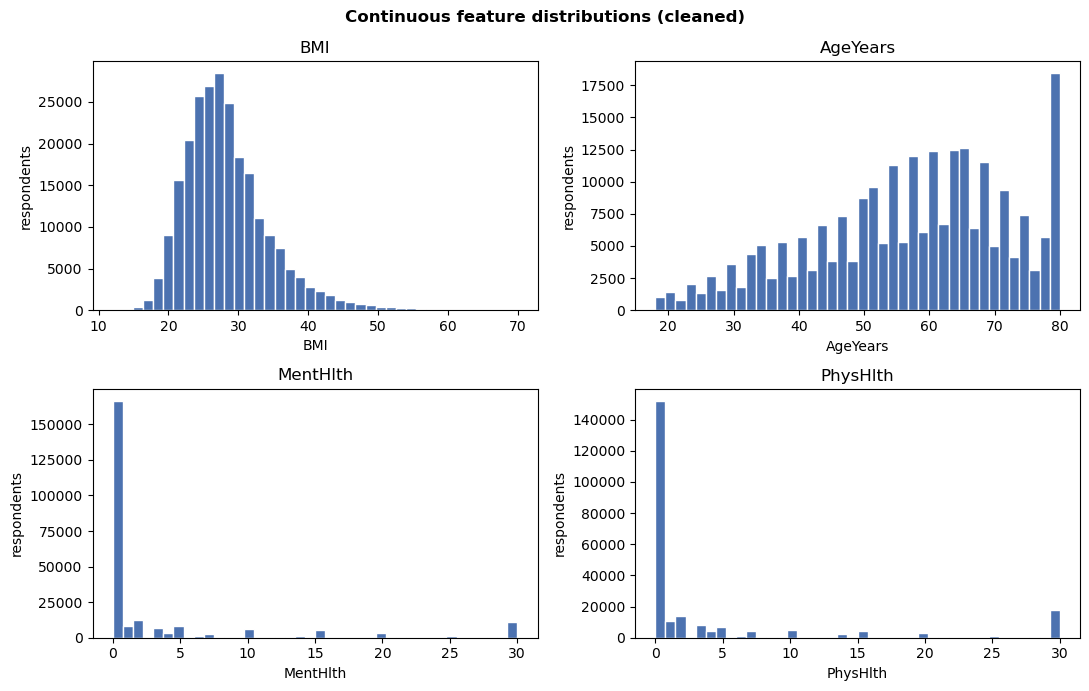

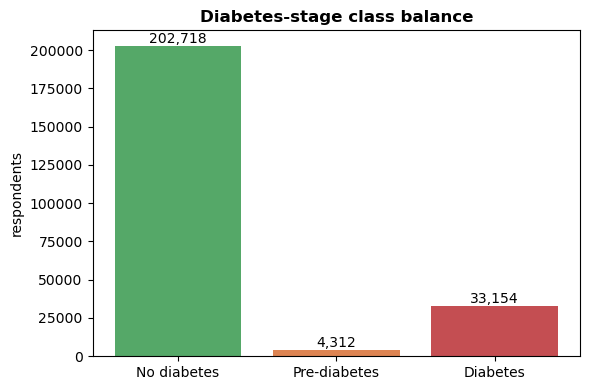

In [9]:
# Distributions of the continuous features (after cleaning)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.ravel(), NUMERIC):
    ax.hist(clean[c], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(c)
    ax.set_xlabel(c)
    ax.set_ylabel('respondents')
fig.suptitle('Continuous feature distributions (cleaned)', fontweight='bold')
fig.tight_layout()
plt.show()

# Target class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = clean['DiabetesStage'].value_counts().sort_index()
ax.bar([labels[k] for k in counts.index], counts.values,
       color=['#55A868', '#DD8452', '#C44E52'])
ax.set_title('Diabetes-stage class balance', fontweight='bold')
ax.set_ylabel('respondents')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
fig.tight_layout()
plt.show()

In [10]:
# Face validity: share with diabetes (stage 2) by a few key risk factors —
# prevalence should trend up with obesity band, high blood pressure, and age.
print('Diabetes prevalence (stage==2) by risk factor — should trend up:')
diab = (clean['DiabetesStage'] == 2)
for col in ['BMICategory', 'HighBP', 'Age']:
    print(f'\n  by {col}:')
    print((diab.groupby(clean[col]).mean() * 100).round(1).to_string())

Diabetes prevalence (stage==2) by risk factor — should trend up:

  by BMICategory:
BMICategory
1     5.4
2     5.9
3    11.8
4    24.1

  by HighBP:
HighBP
0     6.0
1    24.3

  by Age:
Age
1      1.3
2      1.8
3      2.9
4      4.5
5      6.5
6      8.7
7     11.6
8     13.7
9     17.1
10    20.1
11    21.8
12    21.2
13    18.4


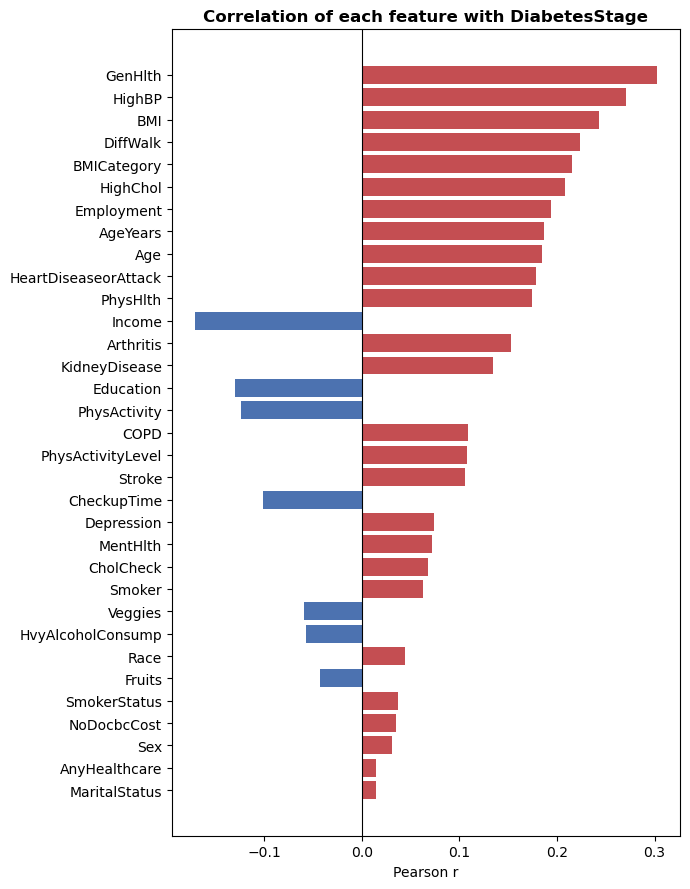

Top 10 features by |correlation| with DiabetesStage:
GenHlth                 0.302
HighBP                  0.271
BMI                     0.243
DiffWalk                0.224
BMICategory             0.215
HighChol                0.209
Employment              0.194
AgeYears                0.187
Age                     0.185
HeartDiseaseorAttack    0.179


In [11]:
# How strongly does each feature move with diabetes stage?
# (Pearson r against the ordinal 0/1/2 target — a quick linear-signal ranking.)
corr = clean.corr(numeric_only=True)['DiabetesStage'].drop('DiabetesStage')
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 9))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in corr.values[::-1]]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors)
ax.axvline(0, color='k', lw=.8)
ax.set_title('Correlation of each feature with DiabetesStage', fontweight='bold')
ax.set_xlabel('Pearson r')
fig.tight_layout()
plt.show()

print('Top 10 features by |correlation| with DiabetesStage:')
print(corr.head(10).round(3).to_string())

## 9. Save the cleaned dataset

The table is now recoded, complete-case, range-validated and outlier-screened —
ready for the modelling notebook.

In [12]:
clean.to_csv(CLEAN_PATH, index=False)
print(f'Saved cleaned dataset -> {CLEAN_PATH}')
print(f'{clean.shape[0]:,} rows × {clean.shape[1]} columns')
print('\nColumns:', ', '.join(clean.columns))

Saved cleaned dataset -> ../data/processed/diabetes_2015_clean.csv
240,184 rows × 34 columns

Columns: DiabetesStage, HighBP, HighChol, CholCheck, BMI, BMICategory, Smoker, SmokerStatus, Stroke, HeartDiseaseorAttack, KidneyDisease, COPD, Arthritis, Depression, PhysActivity, PhysActivityLevel, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, AgeYears, Race, MaritalStatus, Education, Income, Employment, CheckupTime


## Notes & decisions

* **Target choice.** `DIABETE3` is the only diabetes-status question in BRFSS, so
  the three stages (no / pre-diabetes / diabetes) come directly from it. Pre-diabetes
  is a small class (~1.8%) — for a binary model just collapse stage 1 into 0 or 2.
* **Added comorbid cofactors.** Beyond the classic set we include conditions that
  strongly co-occur with / raise the risk of type-2 diabetes: `KidneyDisease`,
  `COPD`, `Arthritis`, `Depression`, plus richer `SmokerStatus`,
  `PhysActivityLevel`, `Employment` and a continuous `AgeYears`. (Kidney/heart
  disease can be both risk factor *and* consequence of diabetes — treat them as
  correlates, not proven causes.)
* **`_`-prefixed sources** (`_RFHYPE5`, `_BMI5`, `_MICHD`, `_TOTINDA`, `_PACAT1`,
  `_FRTLT1`, `_VEGLT1`, `_RFDRHV5`, `_SMOKER3`, `_AGEG5YR`, `_AGE80`, `_RACE`,
  `_BMI5CAT`) are CDC's pre-derived variables — already edited for skip patterns
  and out-of-range values.
* **Deliberately excluded to avoid leakage**: `DIABAGE2` (age at diabetes dx),
  `PDIABTST`, `PREDIAB1`, `INSULIN`, `BLDSUGAR` — these are only asked *because*
  someone already has (pre-)diabetes, so they would leak the target.
* **`_DRNKWEK` (drinks/week) skipped**: alcohol is already captured by
  `HvyAlcoholConsump`, and its implied-decimal scaling is easy to misread.
* **Dropped ~295 columns**: survey administration, weighting, and disease modules
  unrelated to diabetes risk (cancer screening, caregiving, HIV testing, etc.).
* **Missingness audit (§5)**: before dropping we report missingness per column, so the
  complete-case loss is transparent and a modeller can see which fields to impute.
* **Complete-case only**: we drop rather than impute. Swap the `dropna` in §6 for a
  `SimpleImputer` inside a modelling pipeline if you prefer to retain more rows.
* **Range validation (§7)**: every recoded column is asserted to lie inside its
  documented domain — a regression test that the §4 recode logic is correct.
* **Duplicates kept (§7)**: exact duplicate rows exist but are expected with 34
  mostly binary/ordinal features, so they are reported, not removed (dropping them
  would distort the class balance).
* **BMI outliers (§7)**: BMI is right-skewed, so the 1.5×IQR fence would wrongly flag
  every obese respondent. We instead remove only *clinically implausible* BMI
  (outside 12–70); `AgeYears`/`MentHlth`/`PhysHlth` are bounded/top-coded and left
  untouched.
* **EDA (§8)**: summary stats, distribution plots, class balance and
  feature-vs-target correlation document the dataset and confirm expected
  risk-factor trends.
* **Sleep excluded**: no general sleep-duration item exists in BRFSS 2015 core.